# F8 · Profundidad: modos × prompts sobre los cuatro elegidos

**Qué pregunta responde.** Si el tiempo aporta (factor modo) y cuántos clics necesita el
biólogo (factor prompt), sobre los **k = 4** que salieron del cribado, uno por familia:
micro-sam LM `vit_b`, SAM-Med2D `sam_med2d`, TinySAM `vit_t` y SAM 2.1 `tiny`.

**La celda de M2 sale vacía por dependencia no disponible**, no por falta de tiempo: el
apartado 5.1 lo declara no implementable porque el núcleo no es segmentable en `w1CSU488`.
**M3 solo lo soporta SAM 2.1** de los cuatro, y **M4 lo soportan los cuatro**, comprobado
sobre el paquete.

**Qué hay que haber corrido antes**, una vez por entorno:

```
conda run -n surco-microsam  python scripts/profundidad.py
conda run -n surco-sammed2d  python scripts/profundidad.py
conda run -n surco-tinysam   python scripts/profundidad.py
conda run -n surco-sam21     python scripts/profundidad.py
conda run -n surco-microsam  python scripts/m4_encadenado.py
conda run -n surco-sammed2d  python scripts/m4_encadenado.py
conda run -n surco-tinysam   python scripts/m4_encadenado.py
conda run -n surco-sam21     python scripts/m4_encadenado.py
```

Este notebook corre en **`surco`**.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ / "scripts"))  # los scripts agregan; el notebook solo muestra

from surco import config, figuras, metricas
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

from tabla_profundidad import cargar, rejilla

# salidas/profundidad_surco-*.csv  <- scripts/profundidad.py, en los cuatro
# entornos de la rejilla
tabla = cargar()
malla = rejilla(tabla)

4 entornos, 10620 filas


In [2]:
print("Dice medio entre unidades, S0, n = 17")
print(malla.to_string(float_format=lambda v: f"{v:7.4f}"))
print("\nM2: celda vacía por dependencia no disponible (apartado 5.1).")
ausentes = sorted(set(tabla["modelo"]) - set(tabla[tabla["modo"] == "M3"]["modelo"]))
print(f"M3: no lo soportan {', '.join(ausentes)}.")

Dice medio entre unidades, S0, n = 17
protocolo             P1      P2      P3      P4
modelo      modo                                
microsam_lm M0    0.1576  0.1850  0.2046  0.2812
            M1    0.3389  0.3535  0.3821  0.4429
sam21       M0    0.1859  0.1993  0.2124  0.2681
            M1    0.2243  0.2313  0.2392  0.3305
            M3    0.2489  0.2779  0.2580  0.4269
sammed2d    M0    0.2410  0.2496  0.2308  0.2428
            M1    0.3284  0.3320  0.3096  0.3292
tinysam     M0    0.1514  0.1494  0.1880  0.2010
            M1    0.2399  0.2534  0.2451  0.3444

M2: celda vacía por dependencia no disponible (apartado 5.1).
M3: no lo soportan microsam_lm, sammed2d, tinysam.


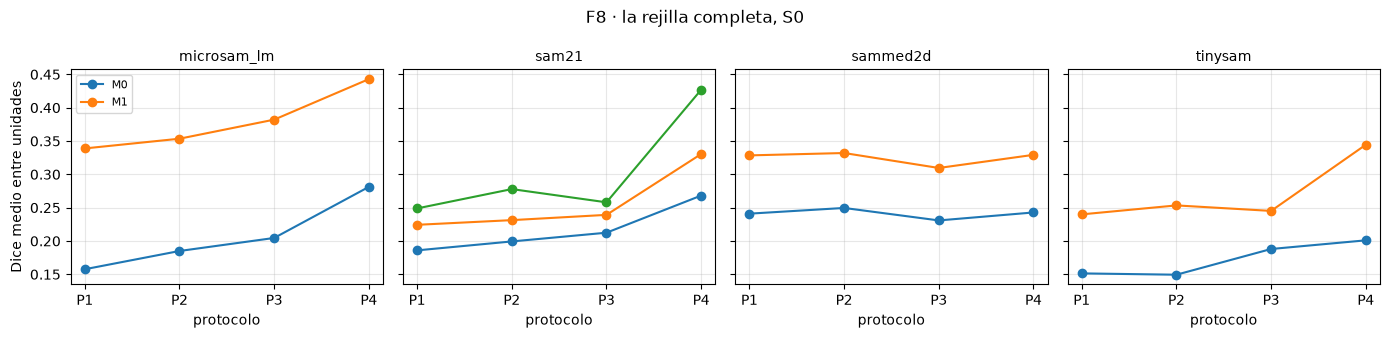

In [3]:
figura, ejes = plt.subplots(1, 4, figsize=(14, 3.4), sharey=True)
for plano, modelo in zip(ejes, sorted(tabla["modelo"].unique())):
    propio = malla.loc[modelo]
    for modo in propio.index:
        plano.plot(propio.columns, propio.loc[modo], marker="o", label=modo)
    plano.set_title(modelo, fontsize=10)
    plano.set_xlabel("protocolo")
    plano.grid(alpha=0.3)
ejes[0].set_ylabel("Dice medio entre unidades")
ejes[0].legend(fontsize=8)
figura.suptitle("F8 · la rejilla completa, S0")
figura.tight_layout()
figuras.guardar(figura, "figura_f8_rejilla.png")

In [4]:
from tabla_profundidad import diferencias_de_modo

diferencias_de_modo(tabla)


=== EL FACTOR MODO, A PROTOCOLO FIJO ===
 microsam_lm
  microsam_lm/M1/P1 menos microsam_lm/M0/P1: +0.1813 [+0.1007, +0.2727], gana en 16 de 17
  microsam_lm/M1/P2 menos microsam_lm/M0/P2: +0.1685 [+0.0931, +0.2546], gana en 16 de 17
  microsam_lm/M1/P3 menos microsam_lm/M0/P3: +0.1775 [+0.1011, +0.2606], gana en 16 de 17
  microsam_lm/M1/P4 menos microsam_lm/M0/P4: +0.1617 [+0.0845, +0.2375], gana en 14 de 17
 sam21
  sam21/M1/P1 menos sam21/M0/P1: +0.0383 [-0.0221, +0.1113], gana en 10 de 17
  sam21/M1/P2 menos sam21/M0/P2: +0.0320 [-0.0316, +0.1106], gana en 7 de 17
  sam21/M1/P3 menos sam21/M0/P3: +0.0268 [-0.0387, +0.0980], gana en 8 de 17
  sam21/M1/P4 menos sam21/M0/P4: +0.0623 [-0.0217, +0.1568], gana en 8 de 17
  sam21/M3/P1 menos sam21/M1/P1: +0.0246 [-0.0459, +0.1053], gana en 10 de 17
  sam21/M3/P2 menos sam21/M1/P2: +0.0466 [-0.0428, +0.1498], gana en 12 de 17
  sam21/M3/P3 menos sam21/M1/P3: +0.0188 [-0.0758, +0.1268], gana en 11 de 17
  sam21/M3/P4 menos sam21/M1/P4: +0

In [5]:
from tabla_profundidad import diferencias_de_protocolo

diferencias_de_protocolo(tabla)


=== EL FACTOR PROMPT, EN M1 ===
 microsam_lm
  microsam_lm/M1/P2 menos microsam_lm/M1/P1: +0.0146 [+0.0017, +0.0298], gana en 11 de 17
  microsam_lm/M1/P3 menos microsam_lm/M1/P1: +0.0432 [+0.0020, +0.0840], gana en 13 de 17
  microsam_lm/M1/P4 menos microsam_lm/M1/P1: +0.1040 [+0.0512, +0.1607], gana en 14 de 17
 sam21
  sam21/M1/P2 menos sam21/M1/P1: +0.0070 [-0.0140, +0.0273], gana en 10 de 17
  sam21/M1/P3 menos sam21/M1/P1: +0.0149 [-0.0251, +0.0588], gana en 11 de 17
  sam21/M1/P4 menos sam21/M1/P1: +0.1062 [+0.0512, +0.1670], gana en 13 de 17
 sammed2d


  sammed2d/M1/P2 menos sammed2d/M1/P1: +0.0036 [-0.0115, +0.0190], gana en 7 de 17
  sammed2d/M1/P3 menos sammed2d/M1/P1: -0.0189 [-0.0443, +0.0077], gana en 5 de 17
  sammed2d/M1/P4 menos sammed2d/M1/P1: +0.0008 [-0.0294, +0.0325], gana en 10 de 17
 tinysam
  tinysam/M1/P2 menos tinysam/M1/P1: +0.0135 [-0.0027, +0.0299], gana en 11 de 17
  tinysam/M1/P3 menos tinysam/M1/P1: +0.0052 [-0.0179, +0.0287], gana en 8 de 17
  tinysam/M1/P4 menos tinysam/M1/P1: +0.1045 [+0.0575, +0.1565], gana en 15 de 17


In [6]:
# M4, el cuarto modo: encadenar la mascara de t-1 junto con los clics. M1 es el
# modo que tiene que superar, porque el fallo que ataca es el del clic fijo.
from tabla_m4 import cargar as cargar_m4, comparar, m4_contra_m3, por_posicion_en_la_cadena

# salidas/m4_surco-*.csv  <- scripts/m4_encadenado.py, en los cuatro entornos.
# El M1 de referencia sale de profundidad_surco-*.csv para S0 y de selector.csv
# para S1, sin volver a calcularlo.
m4, referencias = cargar_m4()
contra_m1 = comparar(m4, referencias)
print(contra_m1.to_string(index=False, float_format=lambda v: f"{v:7.4f}"))
fuera = contra_m1[(contra_m1["ic_bajo"] > 0) | (contra_m1["ic_alto"] < 0)]
print(f"\nceldas cuyo intervalo no cruza el cero: {len(fuera)} de {len(contra_m1)}")

     modelo selector protocolo  dice_m1  dice_m4  m4_menos_m1  ic_bajo  ic_alto  ganadas  de
microsam_lm       S0        P1   0.3389   0.3327      -0.0062  -0.0213   0.0079        8  17
microsam_lm       S0        P2   0.3535   0.3470      -0.0065  -0.0245   0.0124        8  17
microsam_lm       S0        P3   0.3821   0.3645      -0.0176  -0.0540   0.0114        9  17
microsam_lm       S0        P4   0.4429   0.4454       0.0025  -0.0249   0.0286       10  17
microsam_lm       S1        P1   0.3458   0.3142      -0.0316  -0.0637  -0.0051        5  17
microsam_lm       S1        P2   0.3194   0.3093      -0.0101  -0.0371   0.0175        7  17
microsam_lm       S1        P3   0.4184   0.4158      -0.0026  -0.0286   0.0213        7  17
microsam_lm       S1        P4   0.5264   0.5517       0.0253   0.0013   0.0510       12  17
      sam21       S0        P1   0.2243   0.2918       0.0675   0.0251   0.1162       14  17
      sam21       S0        P2   0.2313   0.2928       0.0615  -0.0079

In [7]:
# Los dos modos temporales cara a cara, en el unico modelo que tiene los dos.
print("SAM 2.1, M4 contra M3 (S0):")
print(m4_contra_m3(m4).to_string(index=False, float_format=lambda v: f"{v:7.4f}"))

# Y como se comporta la cadena segun cuantos frames lleva encadenados: un
# desplazamiento constante es un sesgo, una caida con el paso es deriva.
print("\nSegun la posicion en la cadena (S0, media de los protocolos):")
print(por_posicion_en_la_cadena(m4, referencias).to_string(index=False, float_format=lambda v: f"{v:7.4f}"))

SAM 2.1, M4 contra M3 (S0):
protocolo  dice_m3  dice_m4  m4_menos_m3  ic_bajo  ic_alto  ganadas  de
       P1   0.2489   0.2918       0.0429  -0.0575   0.1462        9  17
       P2   0.2779   0.2928       0.0150  -0.0929   0.1198       10  17
       P3   0.2580   0.3063       0.0483  -0.0568   0.1528       11  17
       P4   0.4269   0.5134       0.0864  -0.0244   0.1887       12  17

Segun la posicion en la cadena (S0, media de los protocolos):
     modelo    m4_1    m1_1  m4_2-5  m1_2-5  m4_6-11  m1_6-11  m4_12+  m1_12+
microsam_lm  0.3945  0.3796  0.3764  0.3940   0.3743   0.3960  0.3457  0.3365
      sam21  0.3811  0.3021  0.4057  0.3174   0.3694   0.2492  0.2801  0.1983
   sammed2d  0.3009  0.3722  0.1862  0.3589   0.0535   0.3172  0.0204  0.3017
    tinysam  0.3355  0.3052  0.3614  0.3421   0.3229   0.2823  0.2398  0.1893
